In [1]:
from pyuvdata import UVData, UVBeam, utils as uvutils
import numpy as np
import hdf5plugin
import copy
import uvtools as uvt
import matplotlib.pyplot as plt
import hera_cal as hc
# import healvis
from scipy.signal import windows
import astropy.io.fits as fits
import pandas as pd
import h5py
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
import glob
import os
import glob
import re

In [3]:
hd_cal_model= io.HERAData(path_data+"single_pol_data_combined_2h_low_LST.uvh5")
times_select=hd_cal_model.times

In [23]:
np.where(np.array(times_select)==2459861.2530233106)

(array([1]),)

In [24]:
np.array(times_select)[1]

np.float64(2459861.2530233106)

In [2]:
N=275
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"


def numerical_sort(value):
    # Find all digit groups and convert them to integers
    numbers = re.findall(r'\d+', value)
    return list(map(int, numbers)) if numbers else [0]

uvh5name = sorted(glob.glob(path_data+"*sum.uvh5"), key=numerical_sort)
uvh5name_diff = sorted(glob.glob(path_data+"*diff.uvh5"), key=numerical_sort)

In [3]:
uvh5name[0]

'/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.25297.sum.uvh5'

In [7]:
n=0
i=4*n
print(i)
# load data
##filter data when filter are used
hd = io.HERAData(uvh5name[i])

SUM_FILE=uvh5name[i]
DIFF_FILE=uvh5name_diff[i]
hd_unfil = io.HERAData(SUM_FILE)
hd_diff = io.HERAData(DIFF_FILE)
times=hd_unfil.times[0:2]
freq_range=hd_unfil.freqs

0


In [8]:
hdm_gleam = io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/gleam_model_final.uvh5")
freq_range_reduced=freq_range[np.where( (hdm_gleam.freqs[0]<=freq_range) & (freq_range <=hdm_gleam.freqs[-1]))]

antenna_diameters are not set or are being overwritten. antenna_diameters are set using values from known telescopes for HERA.


In [10]:
freq_range_reduced

array([1.50070190e+08, 1.50192261e+08, 1.50314331e+08, 1.50436401e+08,
       1.50558472e+08, 1.50680542e+08, 1.50802612e+08, 1.50924683e+08,
       1.51046753e+08, 1.51168823e+08, 1.51290894e+08, 1.51412964e+08,
       1.51535034e+08, 1.51657104e+08, 1.51779175e+08, 1.51901245e+08,
       1.52023315e+08, 1.52145386e+08, 1.52267456e+08, 1.52389526e+08,
       1.52511597e+08, 1.52633667e+08, 1.52755737e+08, 1.52877808e+08,
       1.52999878e+08, 1.53121948e+08, 1.53244019e+08, 1.53366089e+08,
       1.53488159e+08, 1.53610229e+08, 1.53732300e+08, 1.53854370e+08,
       1.53976440e+08, 1.54098511e+08, 1.54220581e+08, 1.54342651e+08,
       1.54464722e+08, 1.54586792e+08, 1.54708862e+08, 1.54830933e+08,
       1.54953003e+08, 1.55075073e+08, 1.55197144e+08, 1.55319214e+08,
       1.55441284e+08, 1.55563354e+08, 1.55685425e+08, 1.55807495e+08,
       1.55929565e+08, 1.56051636e+08, 1.56173706e+08, 1.56295776e+08,
       1.56417847e+08, 1.56539917e+08, 1.56661987e+08, 1.56784058e+08,
      

In [10]:
hdm_gleam.times[0], times[0] 

NameError: name 'hdm_gleam' is not defined

In [11]:
hdm_gleam = io.HERAData(path_data+"Model_gleam_vis_expanded.uvh5")
hdm_gleam.read(times=times[0], frequencies=freq_range_reduced)
# model_data_gleam,_,_=hdm_gleam.build_datacontainers()

ValueError: Frequency 165084838.8671875 is not present in the freq_array.

In [17]:
hdm_gleam.freqs

array([1.40060425e+08, 1.40182495e+08, 1.40304565e+08, 1.40426636e+08,
       1.40548706e+08, 1.40670776e+08, 1.40792847e+08, 1.40914917e+08,
       1.41036987e+08, 1.41159058e+08, 1.41281128e+08, 1.41403198e+08,
       1.41525269e+08, 1.41647339e+08, 1.41769409e+08, 1.41891479e+08,
       1.42013550e+08, 1.42135620e+08, 1.42257690e+08, 1.42379761e+08,
       1.42501831e+08, 1.42623901e+08, 1.42745972e+08, 1.42868042e+08,
       1.42990112e+08, 1.43112183e+08, 1.43234253e+08, 1.43356323e+08,
       1.43478394e+08, 1.43600464e+08, 1.43722534e+08, 1.43844604e+08,
       1.43966675e+08, 1.44088745e+08, 1.44210815e+08, 1.44332886e+08,
       1.44454956e+08, 1.44577026e+08, 1.44699097e+08, 1.44821167e+08,
       1.44943237e+08, 1.45065308e+08, 1.45187378e+08, 1.45309448e+08,
       1.45431519e+08, 1.45553589e+08, 1.45675659e+08, 1.45797729e+08,
       1.45919800e+08, 1.46041870e+08, 1.46163940e+08, 1.46286011e+08,
       1.46408081e+08, 1.46530151e+08, 1.46652222e+08, 1.46774292e+08,
      

In [9]:
uvh5name[0][43:69]

'zen.2459861.25297.sum.uvh5'

In [8]:
baseline=np.load("no_flags_baseline.npy")

In [9]:
bls_select=[]
for i in range (len(baseline)):
    bls_select.append((baseline[i][0],baseline[i][1]))

In [12]:
path_data_model="/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/"
path_data="/net/sinatra/vault-ike/ntsikelelo/Data_H6C/"

hd= io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/zen.2459861.50015.sum.uvh5")
# hd2 = hc.io.HERAData("/net/sinatra/vault-ike/ntsikelelo/Data_H6C/single_pol_data_combined_2h_test.uvh5")
freqs = hd.freq_array
antpos, ants = hd.get_ENU_antpos(pick_data_ants=True)
antpos_d = dict(zip(ants, antpos))

bl_lens = {bl: np.linalg.norm(antpos_d[bl[1]]-antpos_d[bl[0]]) for bl in hd.get_antpairs()}   
# downselect to maximum baseline length (to reduce computational load in calibration)
bls = []
for bl in list(hd.get_antpairs()):
    # max 40 m baseline cut (also cut autos)
    bl_len = np.linalg.norm(antpos_d[bl[1]] - antpos_d[bl[0]])
    if bl_len > 0:
        bls.append(bl[:2])   

time=np.unique(hd.time_array)[0]
# only load a couple of times and frequencies
pol=hd.polarization_array
hd.read(polarizations=pol[0],frequencies=freqs, times=time)
# hd2.read(polarizations=pol[0],frequencies=freqs,times=time)

# hd.conjugate_bls()
# hd._determine_blt_slicing()
# hd._determine_pol_indexing()

# hd2.conjugate_bls()
# hd2._determine_blt_slicing()
# hd2._determine_pol_indexing()

 
hd.x_orientation = 'east'
# hd2.x_orientation = 'east'

hd.select(bls=bls)
  
    # load datacontainer
data, _, _ = hd.build_datacontainers() #xtalk raw data
# model, _, _ = hd2.build_datacontainers() # x-talk model
   


 



        
        




In [13]:
pol=hd.polarization_array

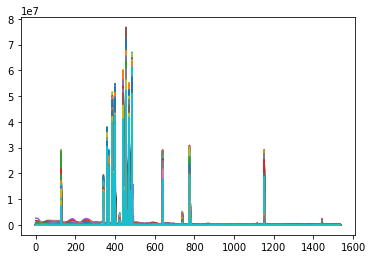

In [14]:
for key in data:
    plt.plot(np.abs(data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [21]:
reds = hc.redcal.get_reds(antpos_d, pols=['ee'])
red_data=[]
for red_g in reds:
    bl_group=[]
    for bl in red_g:
        if bl in list(data.keys()):
            bl_group.append(bl)    
    if len(bl_group)>0:   
        red_data.append(bl_group)    

# rc = hc.redcal.RedundantCalibrator(filtered_reds)
rc = hc.redcal.RedundantCalibrator(red_data)


In [22]:
#get redundant baseline groups in data

Nrms=1e-4

# get noise wgts (use whatever noise RMS you put into the data)
noise_wgts = {k: np.ones_like(data[k], dtype=float) / Nrms**2 for k in data}


#     # perform logcal
logcal_meta, logcal_sol = rc.logcal(data)
hc.redcal.make_sol_finite(logcal_sol)
#remove redcal degeneracies from solution
# logcal_sol = rc.remove_degen(logcal_sol)
#get gains and model visibilities
# logcal_gains, logcal_vis = hc.redcal.get_gains_and_vis_from_sol(logcal_sol)



divide by zero encountered in log
divide by zero encountered in log
invalid value encountered in exp


In [23]:
#perform omnical (lincal)
conv_crit = 1e-10
maxiter = 500
gain = 0.4
lincal_meta, lincal_sol = rc.omnical(data, logcal_sol, wgts=noise_wgts, conv_crit=conv_crit,
                                 maxiter=maxiter, gain=gain)




invalid value encountered in true_divide
invalid value encountered in greater
invalid value encountered in greater


In [24]:
for ant in logcal_sol.gains:

    plt.plot(np.abs(logcal_sol.gains[ant])[0])

AttributeError: 'dict' object has no attribute 'gains'

In [ ]:
for ant in lincal_sol.gains:

    plt.plot(np.abs(lincal_sol.gains[ant])[0])

In [ ]:
for ant in lincal_sol.vis:

    plt.plot(np.abs(lincal_sol.vis[ant])[0])

In [27]:
# figure out appropriate model times to load
matched_model_files=["/net/sinatra/vault-ike/ntsikelelo/Model_Data_H6C/single_pol_model_combined_2h_test.uvh5"]
hdm = io.HERAData(matched_model_files)
times=np.unique(hdm.time_array)
hdm.read(polarizations=pol[0], times=times[0], frequencies=freqs)
model_data,_,_=hdm.build_datacontainers() 


KeyError: "Unable to open object (object 'phase_type' doesn't exist)"

In [69]:
data_bls, model_bls, data_to_model_bl_map=abscal.match_baselines(data_bls=data.keys(), model_bls=model_data.keys(), data_antpos=data.antpos,model_antpos= model_data.antpos, pols=['nn'], data_is_redsol=True,
    model_is_redundant=True, verbose=True)

Selected 134 data baselines and 134 model baselines to load.


In [ ]:
model_data_modi=copy.deepcopy(data)
for i in range (len(model_bls)):
    model_data_modi[data_bls[i]]=model_data[model_bls[i]]


In [ ]:
model_data_modi[data_bls[0]]


In [ ]:
model_data[model_bls[0]]

In [ ]:
# calibration with lincal gains
redcal_data = copy.deepcopy(data)
hc.apply_cal.calibrate_in_place(redcal_data, lincal_sol.gains)

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(redcal_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [ ]:
# calibration with lincal gains
calibrated_data = copy.deepcopy(redcal_data)

In [ ]:
rc_flags = {k: np.zeros_like(lincal_sol.gains[k], dtype=bool) for k in lincal_sol.gains}


In [ ]:
noise_wgts = {k: np.ones_like(redcal_data[k], dtype=float)  for k in redcal_data}

for k in data:

    if k not in data_bls: 

        noise_wgts[k] = np.ones(noise_wgts[k].shape)*1e-40


In [ ]:
abscal_gains = hc.abscal.post_redcal_abscal(model_data_modi, calibrated_data, noise_wgts, rc_flags, verbose=False)

In [ ]:
total_gains = hc.abscal.merge_gains([lincal_sol.gains, abscal_gains])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(abscal_gains[ant])[0])

In [ ]:
for ant in total_gains:

    plt.plot(np.abs(total_gains[ant])[0])

In [ ]:
for key in redcal_data:
    if key in data_bls:
        #plt.plot(np.abs(data[key][0,:]))
        plt.plot(np.abs(calibrated_data[key][0,:]))
# plt.plot(np.abs(model[(27, 48, 'ee')][0,0:100]))

In [28]:
hc.abscal.post_redcal_abscal??

Signature:
hc.abscal.post_redcal_abscal(
    model,
    data,
    data_wgts,
    rc_flags,
    edge_cut=0,
    tol=1.0,
    kernel=(1, 15),
    phs_max_iter=100,
    phs_conv_crit=1e-06,
    verbose=True,
)
Source:   
def post_redcal_abscal(model, data, data_wgts, rc_flags, edge_cut=0, tol=1.0, kernel=(1, 15),
                       phs_max_iter=100, phs_conv_crit=1e-6, verbose=True):
    '''Performs Abscal for data that has already been redundantly calibrated.

    Arguments:
        model: DataContainer containing externally calibrated visibilities, LST-matched to the data.
            The model keys must match the data keys.
        data: DataContainer containing redundantly but not absolutely calibrated visibilities. This gets modified.
        data_wgts: DataContainer containing same keys as data, determines their relative weight in the abscal
            linear equation solvers.
        rc_flags: dictionary mapping keys like (1, 'Jnn') to flag waterfalls from redundant calibratio